In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pathlib

In [ ]:
data = pathlib.Path('/content/drive/My Drive/brain_tumor_two')

In [ ]:
!pip install mplcyberpunk

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import mplcyberpunk
plt.style.use("cyberpunk")
import cv2
import tensorflow as tf
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalMaxPooling2D,GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Dense, Flatten, Dropout, Input, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.metrics import classification_report,confusion_matrix
from tqdm import tqdm # for adding progress bars to loops
from tensorflow.keras.regularizers import l2

# #from bm3d import bm3d, BM3DProfile
from warnings import filterwarnings # for managing warning messages
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
# Data Preparation
X_train = [] # Intializes lists
y_train = []
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']
image_size =340
for i in labels:
    folderPath = os.path.join('/content/drive/My Drive/brain_tumor_two/Training_two',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        X_train.append(img)
        y_train.append(i)

for i in labels:
    folderPath = os.path.join('/content/drive/My Drive/brain_tumor_two/Testing_two',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        y_train.append(i)

X_train = np.array(X_train)
y_train = np.array(y_train)

100%|██████████| 300/300 [00:07<00:00, 42.14it/s] 


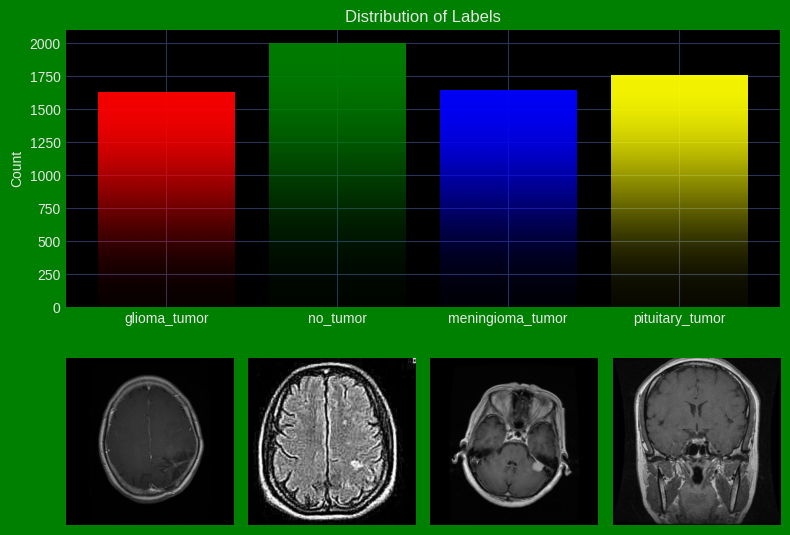

In [ ]:
# Data visualization
# Calculate the bar plot for each label
label_counts = {label: np.sum(y_train == label) for label in labels}

# Plot the bar plot and sample images in one chart
plt.figure(figsize=(8, 6),facecolor='Green')
colors = ['red', 'green', 'blue', 'yellow']

# Plot the histogram
plt.subplot(2, 1, 1,facecolor='black')
bars = plt.bar(label_counts.keys(), label_counts.values(), color=colors)
mplcyberpunk.add_bar_gradient(bars=bars)
# plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Distribution of Labels')

# Plot sample images from each label
k = 0
for i in labels:
    j = 0
    while True:
        if y_train[j] == i:
            plt.subplot(2, 4, k + 5)
            plt.imshow(X_train[j])
            plt.axis('off')
            k += 1
            break
        j += 1

plt.tight_layout()
plt.show()

In [ ]:
X_train, y_train = shuffle(X_train,y_train, random_state=101)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_train,y_train, test_size=0.15,random_state=101)

In [ ]:
print(X_train.max(), X_train.min())
print(X_test.max(), X_test.min())
X_train = X_train/255
X_test = X_test/255
print(X_train.max(), X_train.min())
print(X_test.max(), X_test.min())

255 0
255 0
1.0 0.0
1.0 0.0


In [ ]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Average, Dropout, GlobalAveragePooling2D, BatchNormalization, Activation, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import VGG19,VGG16,ResNet152,MobileNet,InceptionV3,Xception,EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt


# Define the input layer
input_layer = Input(shape=(340, 340, 3))

# Custom CNN model
#l2_values = [0.0001, 0.001, 0.01, 0.1]
l2_values=[0.01]
results = {}

for l2_value in l2_values:
    print(f'Training with L2 regularization: {l2_value}')
cnn_model = Sequential([
    # First convolutional block
    Conv2D(32, (9, 9), padding='same', kernel_regularizer=l2(l2_value), input_shape=(340, 340, 3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (9, 9), padding='same', kernel_regularizer=l2(l2_value)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (9, 9), padding='same', kernel_regularizer=l2(l2_value)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    # Fourth convolutional block
    Conv2D(256, (9, 9), padding='same', kernel_regularizer=l2(l2_value)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(512, (9, 9), padding='same', kernel_regularizer=l2(l2_value)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(1024, (9, 9), padding='same', kernel_regularizer=l2(l2_value)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(2048, (9, 9), padding='same', kernel_regularizer=l2(l2_value)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    GlobalAveragePooling2D(),

    Flatten()
])(input_layer)

# MobileNet model, without the top layer
mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(340, 340, 3))
for layer in mobilenet_base.layers:
    layer.trainable = False  # Freeze VGG16 layers
mobilenet_output = GlobalAveragePooling2D()(mobilenet_base.output)

# Add dense layers to both models
cnn_dense = Dense(2048, activation='relu')(cnn_model)
cnn_dense = Dropout(0.5)(cnn_dense)

mobilenet_dense = Dense(2048, activation='relu')(mobilenet_output)
mobilenet_dense = Dropout(0.5)(mobilenet_dense)

# Ensemble layer - Average the outputs
ensemble_output = Average()([cnn_dense, mobilenet_dense])

# Final output layer
output_layer = Dense(4, activation='softmax')(ensemble_output)  # Assuming 4 classes

# Create the ensemble model
ensemble_model = Model(inputs=[input_layer, mobilenet_base.input], outputs=output_layer)

# Compile the model
ensemble_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display model summary
ensemble_model.summary()

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
tensorboard = TensorBoard(log_dir='logs')
checkpoint = ModelCheckpoint("ensemble_model_MobileNet.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-7, verbose=1)

# Train the model
class_weights = {0: 2.0, 1: 2.0, 2: 2.0, 3: 2.0}  # Adjust based on class imbalance if necessary

history = ensemble_model.fit(

    [X_train, X_train],  # Duplicate X_train for both input branches
    y_train,
    validation_split=0.15,
    epochs=50,
    verbose=1,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping, tensorboard, checkpoint, reduce_lr]
)



# Evaluate the model
scores = ensemble_model.evaluate([X_test, X_test], y_test)  # Duplicate X_test for both input branches
print("Test Accuracy:", scores[1])


Training with L2 regularization: 0.01


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
<ipython-input-12-ab375e0a527f>:67: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_base = MobileNet(weights='imagenet', include_top=False, input_shape=(340, 340, 3))


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 340, 340, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1 (Conv2D)            │ (None, 170, 170, 32)   │            864 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 170, 170, 32)   │            128 │ conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (ReLU)         │ (None, 170, 170, 32)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1                 │ (None, 170, 170, 32)   │            288 │ conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_bn              │ (None, 170, 170, 32)   │            128 │ conv_dw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_1_relu (ReLU)     │ (None, 170, 170, 32)   │              0 │ conv_dw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1 (Conv2D)        │ (None, 170, 170, 64)   │          2,048 │ conv_dw_1_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_bn              │ (None, 170, 170, 64)   │            256 │ conv_pw_1[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_1_relu (ReLU)     │ (None, 170, 170, 64)   │              0 │ conv_pw_1_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pad_2                │ (None, 171, 171, 64)   │              0 │ conv_pw_1_relu[0][0]   │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2                 │ (None, 85, 85, 64)     │            576 │ conv_pad_2[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_bn              │ (None, 85, 85, 64)     │            256 │ conv_dw_2[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_dw_2_relu (ReLU)     │ (None, 85, 85, 64)     │              0 │ conv_dw_2_bn[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2 (Conv2D)        │ (None, 85, 85, 128)    │          8,192 │ conv_dw_2_relu[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_pw_2_bn         

 Total params: 235,997,828 (900.26 MB)

 Trainable params: 232,760,836 (887.91 MB)

 Non-trainable params: 3,236,992 (12.35 MB)

Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.6873 - loss: 24.2502
Epoch 1: val_accuracy improved from -inf to 0.93534, saving model to ensemble_model_MobileNet.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 151s 631ms/step - accuracy: 0.6880 - loss: 24.1740 - val_accuracy: 0.9353 - val_loss: 1.3528 - learning_rate: 0.0010
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8807 - loss: 1.6075
Epoch 2: val_accuracy did not improve from 0.93534
159/159 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.8807 - loss: 1.6066 - val_accuracy: 0.9353 - val_loss: 0.6905 - learning_rate: 0.0010
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9156 - loss: 0.9406
Epoch 3: val_accuracy did not improve from 0.93534
159/159 ━━━━━━━━━━━━━━━━━━━━ 22s 136ms/step - accuracy: 0.9156 - loss: 0.9408 - val_accuracy: 0.7938 - val_loss: 2.8723 - learning_rate: 0.0010
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9310 - loss: 1.0330
Epoch 4: va

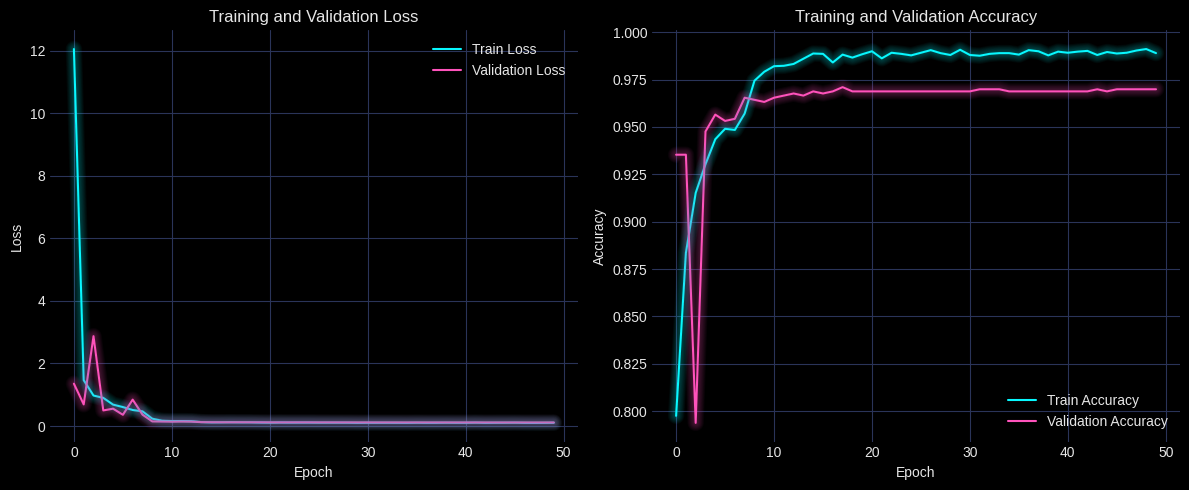

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5),facecolor="black")

plt.subplot(1, 2, 1,facecolor='black')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
mplcyberpunk.make_lines_glow()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2,facecolor='black')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
mplcyberpunk.make_lines_glow()

plt.tight_layout()
plt.show()

33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step


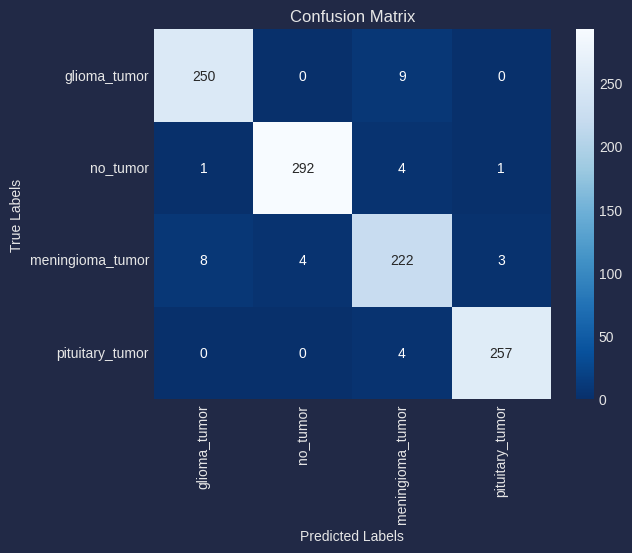

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure `labels` is defined with your class names, e.g., labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

# Calculate true and predicted labels
y_true_test = np.argmax(y_test, axis=1)
y_pred_test = np.argmax(ensemble_model.predict([X_test, X_test]), axis=1)  # Use ensemble_model here

# Plot confusion matrix
heatmap = sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt='d', cmap='Blues_r',
                      xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
print(classification_report(y_true_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       259
           1       0.99      0.98      0.98       298
           2       0.93      0.94      0.93       237
           3       0.98      0.98      0.98       261

    accuracy                           0.97      1055
   macro avg       0.97      0.97      0.97      1055
weighted avg       0.97      0.97      0.97      1055



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted label: meningioma_tumor
Actual label: meningioma_tumor
Confidence: 99.90%



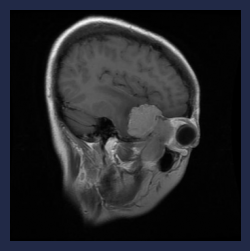

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define your class labels
labels = ['glioma_tumor','no_tumor','meningioma_tumor','pituitary_tumor']

# Select a random image from the test set
random_index = np.random.randint(0, len(X_test))
random_img = X_test[random_index]

# Make a prediction using ensemble_model
predictions = ensemble_model.predict([random_img.reshape(1, 340, 340, 3), random_img.reshape(1, 340, 340, 3)])  # Reshape for both input branches

# Interpret the model's predictions
predicted_class = np.argmax(predictions)  # Get the index of the class with the highest probability
predicted_label = labels[predicted_class]  # Convert class index to label
confidence = predictions[0][predicted_class]  # Get the confidence score

# Get the actual class label
actual_index = y_test[random_index]  # Get the one-hot encoded actual class
actual_class = np.argmax(actual_index)
actual_label = labels[actual_class]

# Display the image and prediction information
print(f"\033[94mPredicted label: {predicted_label}\033[0m")
print(f"\033[92mActual label: {actual_label}\033[0m")
print(f"\033[95mConfidence: {confidence*100:.2f}%\033[0m\n")

# Show the image
plt.figure(figsize=(3, 3))
plt.imshow(random_img)
plt.axis('off')
plt.show()


In [ ]:
# Evaluate the model with duplicated inputs for testing
test_loss, test_accuracy = ensemble_model.evaluate([X_test, X_test], y_test, verbose=1)  # Provide both inputs
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")




33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9609 - loss: 0.1577
Test Accuracy: 96.78%
